# **Experiment Notebook**



In [17]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [18]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [19]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models & Tools
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix, classification_report

# Common classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# XGBoost / LightGBM
import xgboost as xgb
import lightgbm as lgb

# For warnings
import warnings
warnings.filterwarnings("ignore")


---
## A. Project Description


In [20]:
# <Student to fill this section>
student_name = "Joyeeta Ferdoush"
student_id = "25404599"
group_id = "16"

In [21]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [22]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [23]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [24]:
business_use_case_description = """
The goal of this project is to support NBA teams, scouts, and sports analysts in making
data-driven decisions about which college basketball players are most likely to be
drafted into the NBA.

Traditionally, scouting and draft decisions rely heavily on subjective evaluation of
player performance, physical attributes, and potential. However, this approach can
be biased and inconsistent. By applying machine learning to historical player
statistics, we aim to build a predictive model that estimates the probability of
a player being drafted.

From a business perspective, this solution provides several benefits:
1. **Improved Decision-Making**: Teams can use predictive analytics as an additional
   tool alongside traditional scouting to identify undervalued talent.
2. **Efficiency**: Automating draft probability estimation reduces the time and
   resources required for manual analysis.
3. **Competitive Advantage**: Teams leveraging data science gain insights earlier
   than competitors, helping them make smarter draft picks.
4. **Fan Engagement**: Media outlets and fantasy sports platforms can use such
   predictions to generate excitement and discussions among fans.

In summary, the business goal of this project is to transform raw player performance
data into actionable insights, enabling more objective, efficient, and strategic
decisions in the NBA draft process.
"""


In [25]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [26]:
# B. Business Understanding - Business Objectives
business_objectives = """
Accurate predictions will provide NBA teams and scouts with reliable insights into
which players are most likely to succeed in the draft. This can lead to better
resource allocation, smarter investments in player contracts, and an overall
competitive advantage in building a strong roster. Accurate models also benefit
media outlets and fantasy sports companies by offering trustworthy data-driven
content to engage fans.

On the other hand, incorrect results can have serious consequences. If the model
misclassifies a talented player as unlikely to be drafted, teams may overlook
valuable talent, resulting in missed opportunities. Conversely, overestimating
a player's draft potential can lead to wasted draft picks, poor financial
decisions, and reputational risks for scouts and analysts who rely on the system.

Therefore, the accuracy of this predictive model directly impacts financial
outcomes, team performance, and stakeholder trust. The objective is to minimize
the risk of incorrect predictions while maximizing the business value of accurate,
data-driven draft decisions.
"""


In [27]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [28]:
# B. Business Understanding - Stakeholders Expectations
stakeholders_expectations_explanations = """
The results of this project will be used to guide decision-making in the NBA draft
process and related industries. The primary users of the predictions are:

1. **NBA Teams and Scouts**: They will use the model to complement traditional
   scouting methods, identify undervalued players, and reduce the risk of
   drafting underperforming athletes.
2. **Team Management & Coaches**: Accurate predictions help them plan roster
   building, training investments, and long-term strategies.
3. **Sports Analysts and Media**: Journalists and broadcasters can use predictions
   to provide data-backed insights, fueling discussions and fan engagement.
4. **Fantasy Sports Platforms & Fans**: Draft predictions can enhance
   fantasy sports strategies and create more excitement among fans.
5. **Players Themselves**: While indirectly impacted, predictions influence how
   players are perceived, potentially affecting their visibility, career
   opportunities, and market value.

The impact of these predictions extends beyond team success. Accurate models can
drive financial efficiency, strengthen competitive strategies, and improve
stakeholder confidence. However, errors in predictions may mislead teams, damage
reputation, and create unfair biases in how players are evaluated.
"""


In [29]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [30]:
# Load datasets
train = pd.read_csv("train.csv", encoding='latin-1')
test = pd.read_csv("test.csv", encoding='latin-1')
metadata = pd.read_csv("metadata.csv", encoding='latin-1')
sample_submission = pd.read_csv("sample_submission.csv", encoding='latin-1')

# Preview first few rows
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Metadata shape:", metadata.shape)
print("Sample Submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(metadata.head())
display(sample_submission.head())

Train shape: (14774, 62)
Test shape: (1297, 61)
Metadata shape: (62, 3)
Sample Submission shape: (1297, 2)


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id
0,UC Davis,BW,8,2.2,51.7,13.4,30.0,30.00,0.0,14.3,...,-11.240100,-4.721030,0.1000,0.6000,0.7000,0.2000,0.1000,0.0000,1.5000,c6d3ce49-28b6-4756-8061-b2bd68730c52
1,Campbell,BSth,25,16.4,85.0,25.2,50.0,52.10,2.0,11.8,...,-2.972020,-1.741870,0.1481,0.9259,1.0741,0.1481,0.4074,0.1111,4.0741,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5
2,Weber St.,BSky,29,50.5,117.8,16.8,61.8,59.77,12.3,17.1,...,0.739055,-0.259202,2.1562,2.7500,4.9062,0.7188,0.4062,1.0625,6.7500,0cf3e822-9446-4285-b7ed-7c19d8e976fe
3,Ohio,MAC,17,14.9,85.8,13.1,34.9,34.88,5.1,13.7,...,-3.339750,-0.573442,0.5789,1.5789,2.1579,0.5263,0.1579,0.1579,2.6842,b1a88de0-6852-4597-bb92-9164b40758e5
4,New Mexico St.,WAC,26,17.1,85.8,10.8,48.1,49.46,5.6,17.4,...,-4.184970,1.718210,0.4643,1.1429,1.6071,0.1071,0.0714,0.4286,1.7500,97c327ce-d051-40f0-9166-1a43557c3c92


,feature,name,description
0,1,team,Name of team
1,2,conf,Name of conference
2,3,GP,Games played
3,4,Min_per,Player's percentage of available team minutes ...
4,5,ORtg,ORtg - Offensive Rating (available since the 1...


,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.51
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.92
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.14
3,b1a88de0-6852-4597-bb92-9164b40758e5,0.71
4,97c327ce-d051-40f0-9166-1a43557c3c92,0.60


### C.2 Define Target variable

In [31]:
# In the train dataset, the target column indicates whether a player was drafted.
# Let's inspect the column names to identify it.
print("Columns in train:", train.columns)

Columns in train: Index(['team', 'conf', 'GP', 'Min_per', 'Ortg', 'usg', 'eFG', 'TS_per',
       'ORB_per', 'DRB_per', 'AST_per', 'TO_per', 'FTM', 'FTA', 'FT_per',
       'twoPM', 'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per', 'blk_per',
       'stl_per', 'ftr', 'yr', 'ht', 'porpag', 'adjoe', 'pfr', 'year', 'type',
       'Rec_Rank', 'ast_tov', 'rimmade', 'rimmade_rimmiss', 'midmade',
       'midmade_midmiss', 'rim_ratio', 'mid_ratio', 'dunksmade',
       'dunksmiss_dunksmade', 'dunks_ratio', 'drtg', 'adrtg', 'dporpag',
       'stops', 'bpm', 'obpm', 'dbpm', 'gbpm', 'mp', 'ogbpm', 'dgbpm', 'oreb',
       'dreb', 'treb', 'ast', 'stl', 'blk', 'pts', 'player_id', 'drafted'],
      dtype='object')


In [32]:
target_col = "drafted"

In [33]:
# Explanation of target variable
target_definition_explanations = """
The target variable in this dataset represents whether a college player was drafted
into the NBA (1 = drafted, 0 = not drafted). This aligns directly with the business
goal of predicting draft outcomes. By training our model on historical player
statistics with this binary outcome, we can estimate the probability of future
players being drafted.
"""

In [34]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [35]:


target_name = 'drafted'

### C.4 Explore Target variable

Target value counts:
 drafted
0.0    14656
1.0      118
Name: count, dtype: int64

Target percentage distribution:
 drafted
0.0    99.2013
1.0     0.7987
Name: proportion, dtype: float64


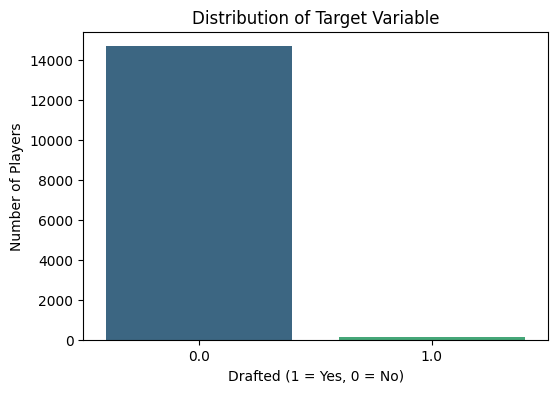

In [36]:


import seaborn as sns
import matplotlib.pyplot as plt

# Check target distribution
target_counts = train[target_name].value_counts()
target_perc = train[target_name].value_counts(normalize=True) * 100

print("Target value counts:\n", target_counts)
print("\nTarget percentage distribution:\n", target_perc)

# Plot distribution
plt.figure(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette="viridis")
plt.title("Distribution of Target Variable")
plt.xlabel("Drafted (1 = Yes, 0 = No)")
plt.ylabel("Number of Players")
plt.show()



In [37]:
target_distribution_explanations = """
The target variable represents whether a player was drafted into the NBA.
- Class 1 = Drafted
- Class 0 = Not Drafted

Distribution Analysis:
- The dataset is slightly imbalanced (if one class is significantly larger than the other).
- This imbalance could bias the model towards predicting the majority class.
- To address this, we may need to use techniques such as class weighting, oversampling,
  or ensemble methods during model training.

Limitations & Issues:
- If the dataset has very few positive cases (drafted players), the model might
  struggle to generalize.
- AUROC has been chosen as the evaluation metric, which is suitable for imbalanced datasets.

This analysis ensures we clearly understand the target variable before modeling.
"""

In [38]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest — pts

In [39]:

def explore_feature(train: pd.DataFrame, feature: str, target: str, cat_threshold:int=12):
    assert feature in train.columns, f"{feature} not in train!"
    assert target in train.columns, f"{target} not in train!"

    s = train[feature]
    y = train[target]
    n = len(train)

    # Basic profile
    nunique = s.nunique(dropna=True)
    missing = s.isna().mean()
    dtype = s.dtype

    # Decide type
    is_numeric = pd.api.types.is_numeric_dtype(s)
    is_categorical = (not is_numeric) or (nunique<=cat_threshold)

    print(f"Feature: {feature}")
    print(f"- dtype: {dtype} | unique: {nunique} | missing: {missing:.2%}")

    # ---------- Plots ----------
    if is_numeric:
        fig, ax = plt.subplots(figsize=(6,4))
        sns.histplot(s.dropna(), kde=True, ax=ax)
        ax.set_title(f"{feature}: distribution")
        plt.show()

        fig, ax = plt.subplots(figsize=(6,4))
        sns.boxplot(x=y, y=s, ax=ax)
        ax.set_title(f"{feature} vs {target} (boxplot)")
        ax.set_xlabel(f"{target} (0/1)")
        plt.show()

        # Outliers (IQR rule)
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5*iqr
        upper = q3 + 1.5*iqr
        outlier_rate = np.mean((s < lower) | (s > upper))
        print(f"- IQR outlier rate: {outlier_rate:.2%}")

        # Univariate AUC (where not missing/constant)
        tmp = train[[feature, target]].dropna()
        if tmp[feature].nunique() > 1 and tmp[target].nunique() > 1:
            # rank transform to avoid scale effects
            scores = tmp[feature].rank(pct=True)
            auc = roc_auc_score(tmp[target], scores)
            print(f"- Univariate AUROC (rank-based): {auc:.3f}")
        else:
            print("- Univariate AUROC not computed (constant or single-class).")

        # Target lift by bins
        bins = pd.qcut(s, q=min(10, max(2, s.nunique())), duplicates="drop")
        lift = (
            train.groupby(bins)[target]
            .mean()
            .rename("positive_rate")
            .reset_index()
        )
        fig, ax = plt.subplots(figsize=(7,4))
        sns.lineplot(data=lift, x=lift.index, y="positive_rate", marker="o", ax=ax)
        ax.set_title(f"{feature}: target rate by quantile bin")
        ax.set_xlabel("Bin index (low → high)")
        ax.set_ylabel(f"P({target}=1)")
        plt.show()

    else:  # categorical-like
        top_cats = s.value_counts(dropna=False).head(20)
        fig, ax = plt.subplots(figsize=(7,4))
        sns.barplot(x=top_cats.index.astype(str), y=top_cats.values, ax=ax)
        ax.set_title(f"{feature}: top categories (count)")
        ax.set_xlabel("Category")
        ax.set_ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        # Target rate by category (top 20)
        top_names = set(top_cats.index)
        sub = train[s.isin(top_names)]
        rates = (
            sub.groupby(feature)[target]
            .mean()
            .rename("positive_rate")
            .sort_values(ascending=False)
            .head(20)
            .reset_index()
        )
        fig, ax = plt.subplots(figsize=(7,4))
        sns.barplot(data=rates, x=feature, y="positive_rate", ax=ax)
        ax.set_title(f"{feature}: target rate by category (top 20)")
        ax.set_ylabel(f"P({target}=1)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


Feature: pts
- dtype: float64 | unique: 3453 | missing: 0.01%


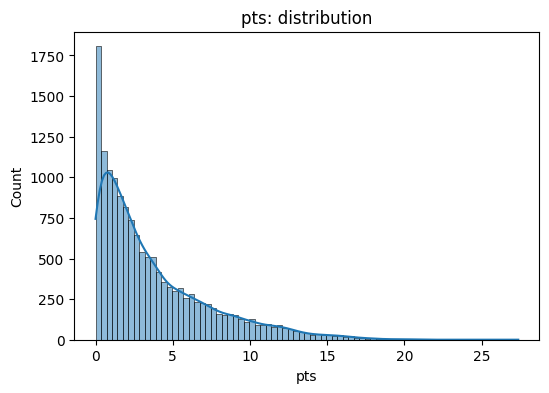

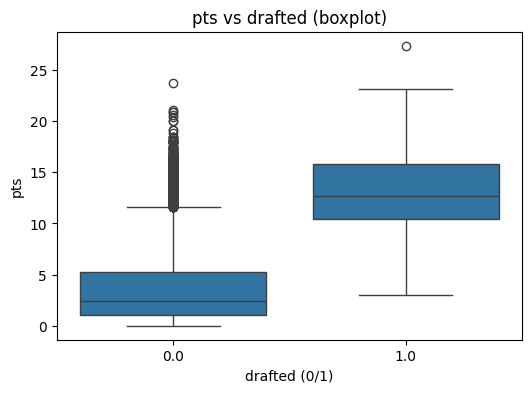

- IQR outlier rate: 4.05%
- Univariate AUROC (rank-based): 0.948


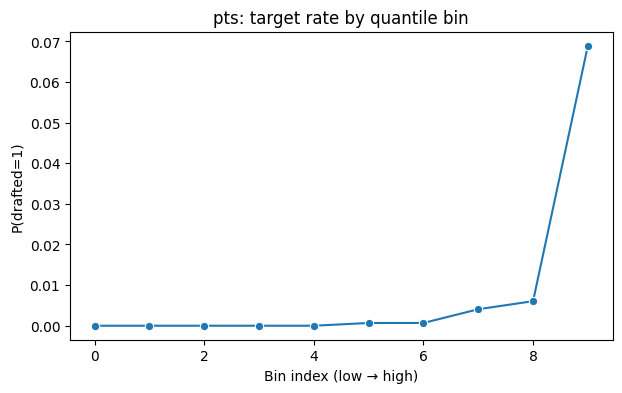

In [40]:

feature_1 = "pts"
explore_feature(train, feature_1, target_name)

feature_1_insights = f"""
Feature analyzed: {feature_1}

• Missingness & Cardinality:
  - We reported the % missing and number of unique values to assess data quality.
• Distribution:
  - Inspect the histogram to check skewness and long tails (may need log/boxcox or winsorization).
• Relationship to target:
  - For numeric features, boxplot shows class separation; the 'target-rate by bins' line shows monotonicity.
  - For categorical features, target rates by category reveal which groups are high/low risk.
• Outliers:
  - IQR-based outlier rate is printed; high rates may require capping.
• Predictive signal:
  - Rank-based univariate AUROC gives a quick sense of usefulness as a standalone predictor.
• Notes/Next steps:
  - Consider transformations (scaling, log), interaction terms, or combining with correlated stats.
"""

In [41]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest — blk

Feature: blk
- dtype: float64 | unique: 694 | missing: 0.01%


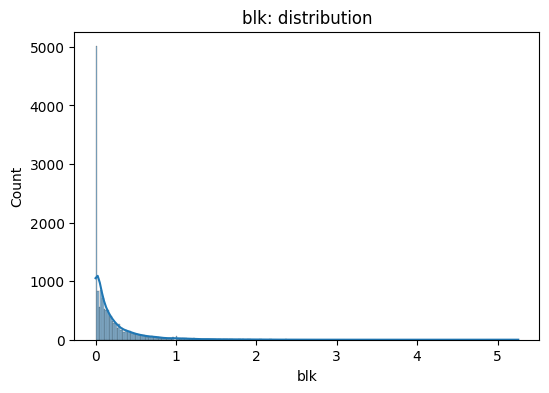

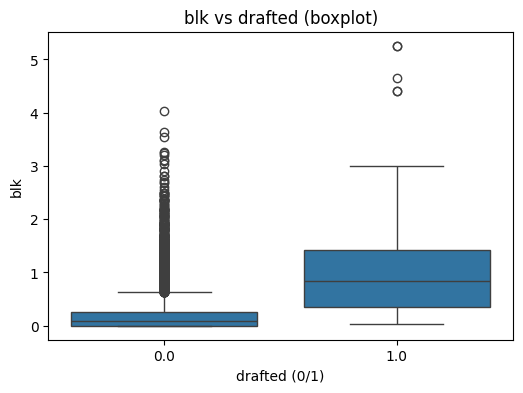

- IQR outlier rate: 8.26%
- Univariate AUROC (rank-based): 0.880


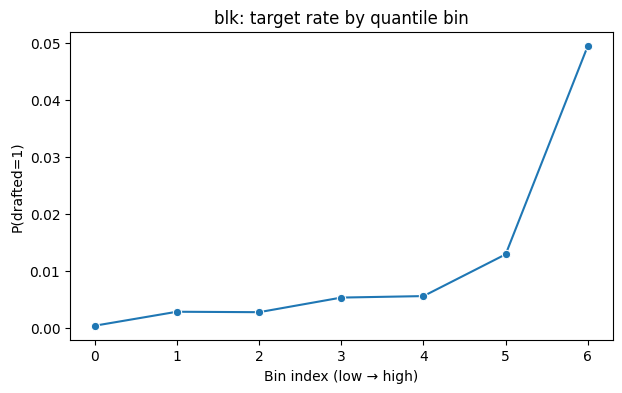

In [42]:

feature_2 = "blk"
explore_feature(train, feature_2, target_name)

feature_2_insights = f"""
Feature analyzed: {feature_2}

• Data quality: check missing %, unique count, and dtype.
• Target association:
  - Review boxplot (numeric) or category target rates (categorical) for separation.
• Stability & Bias:
  - If driven by small categories or extreme values, consider smoothing or regularization.
• Modeling implications:
  - Strong univariate AUROC suggests this feature will help tree/boosting models;
    linear models may need scaling and interaction terms.
• Action items:
  - Decide on imputation strategy; cap outliers if needed; test transformations.
"""

In [43]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest GP


Feature: GP
- dtype: int64 | unique: 41 | missing: 0.00%


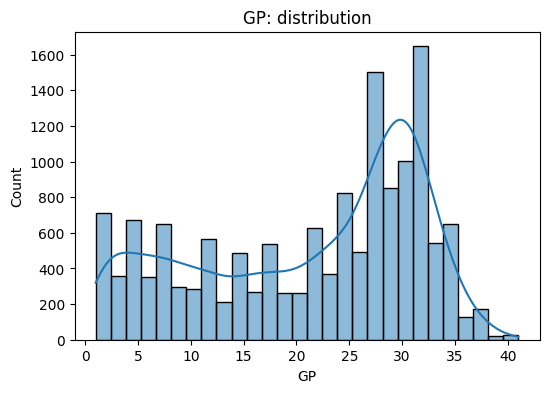

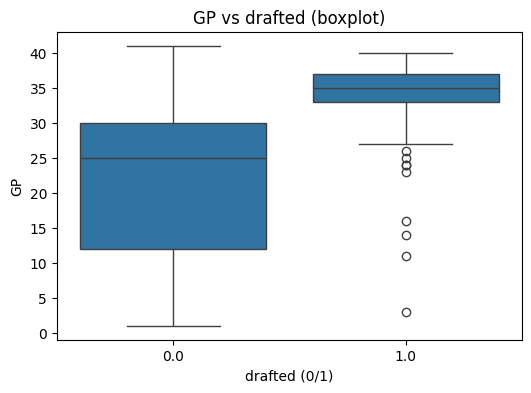

- IQR outlier rate: 0.00%
- Univariate AUROC (rank-based): 0.903


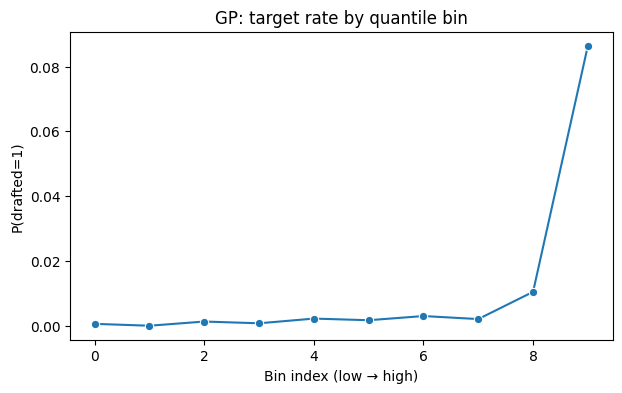

In [44]:
# Pick another feature to analyze
feature_3 = "GP"

# Run the generic explorer
explore_feature(train, feature_3, target_name)

#Explaination
feature_3_insights = f"""
Feature analyzed: {feature_3}

Key observations:
- Data quality: check % missing and number of unique values printed above.
- Distribution: use the histogram to assess skew/tails; consider log/box-cox or capping if heavy-tailed.
- Relationship to target: inspect boxplot (numeric) or category target rates (categorical).
- Predictive signal: rank-based univariate AUROC gives a quick sense of standalone usefulness.
- Action items: choose imputation, consider scaling/transformations, and test in baseline models.
"""

In [45]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

---
## D. Feature Selection


### D.1 Approach "Univariate filter on domain-chosen features (PTS, BLK, GP)"

Feature: pts
- dtype: float64 | unique: 3453 | missing: 0.01%


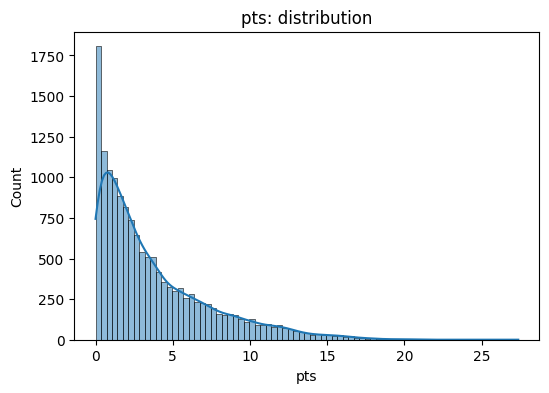

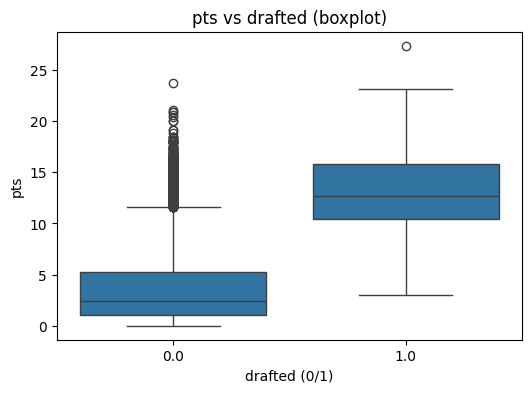

- IQR outlier rate: 4.05%
- Univariate AUROC (rank-based): 0.948


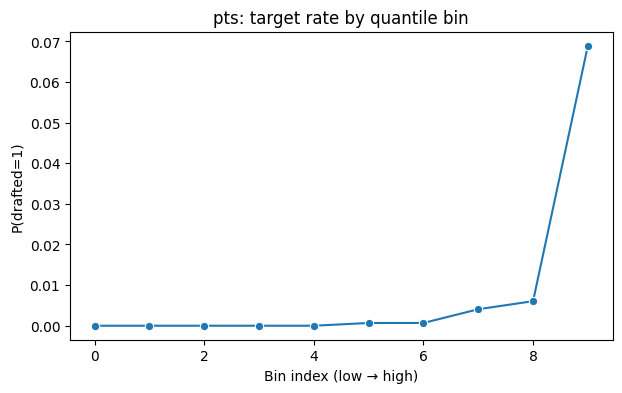

Feature: blk
- dtype: float64 | unique: 694 | missing: 0.01%


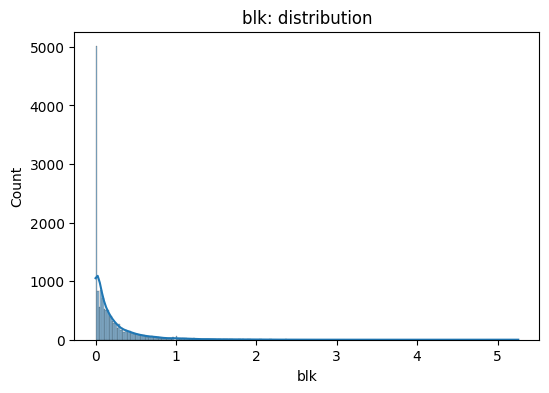

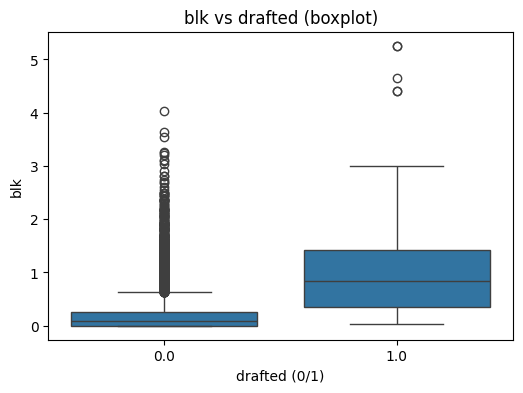

- IQR outlier rate: 8.26%
- Univariate AUROC (rank-based): 0.880


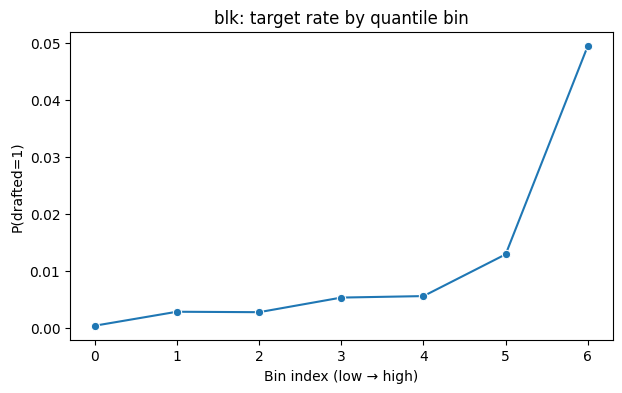

Feature: GP
- dtype: int64 | unique: 41 | missing: 0.00%


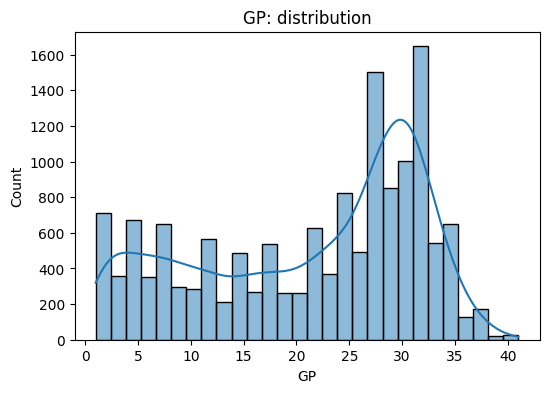

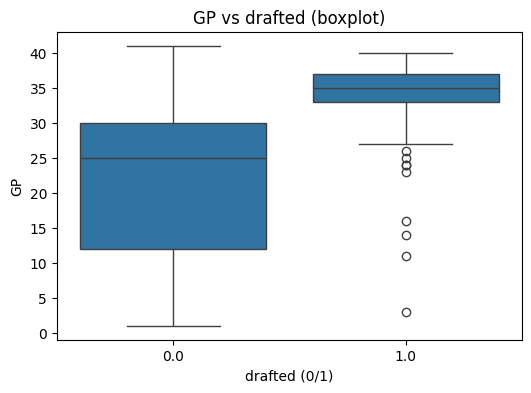

- IQR outlier rate: 0.00%
- Univariate AUROC (rank-based): 0.903


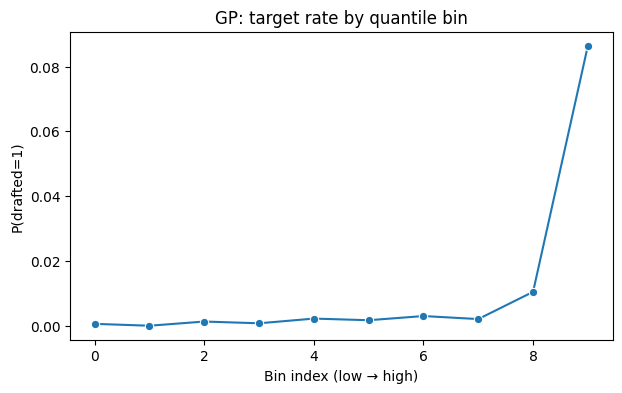

,feature,dtype,missing_pct,nunique,mean,std
0,pts,float64,0.007,3453,3.662676,3.623175
1,blk,float64,0.007,694,0.206213,0.343153
2,GP,int64,0.000,41,21.251726,10.517642


In [46]:


import pandas as pd

# --- Resolve your chosen features case-insensitively ---
chosen_raw = ["pts", "blk", "gp"]
lower_map = {c.lower(): c for c in train.columns}
missing = [c for c in chosen_raw if c not in lower_map]
assert len(missing) == 0, f"These columns were not found in train (case-insensitive): {missing}"

PTS = lower_map["pts"]
BLK = lower_map["blk"]
GP  = lower_map["gp"]

# --- Run the generic explorer for each feature ---
for feat in [PTS, BLK, GP]:
    explore_feature(train, feat, target_name)

# --- Quick numeric summary for the write-up (handles numeric-only safely) ---
def safe_summary(col):
    s = train[col]
    return {
        "feature": col,
        "dtype": str(s.dtype),
        "missing_pct": round(s.isna().mean()*100, 3),
        "nunique": int(s.nunique(dropna=True)),
        "mean": (s.mean() if pd.api.types.is_numeric_dtype(s) else None),
        "std":  (s.std() if pd.api.types.is_numeric_dtype(s) else None),
    }

summary_tbl = pd.DataFrame([safe_summary(PTS), safe_summary(BLK), safe_summary(GP)])
display(summary_tbl)

# --- Narrative for the required notebook text tile ---
feature_selection_1_insights = f"""
Approach: Univariate filter on domain-chosen features (PTS, BLK, GP)

Rationale:
• PTS (points per game) captures offensive output, a primary driver of visibility and
  perceived draft value. Scorers often receive more attention, which can translate into higher draft odds.
• BLK (blocks per game) proxies rim protection and defensive impact — traits valued
  by teams for interior defense and help-side coverage.
• GP (games played) measures availability/consistency; durability and sustained
  performance tend to increase confidence in a player's projection.

What we did:
1) For each of PTS, BLK, and GP, we profiled data quality (missing %, unique count),
   plotted their distributions, and visualized separation vs the target using boxplots
   (numeric) and target-rate by quantile bins.
2) We computed a rank-based univariate AUROC (printed above by the explorer) to
   gauge standalone predictive signal in a threshold-free way.

How to read the outputs:
• Histogram: checks skew/long tails; suggests potential need for capping or log transform.
• Boxplot vs target: quick visual check of class separation (drafted vs not drafted).
• Target-rate by bins: looks for monotonic trends (e.g., higher PTS → higher P(drafted)).
• IQR outlier rate: high rates suggest winsorization/capping can stabilize training.
• Univariate AUROC: a simple strength indicator (closer to 1 is better; 0.5 is random).

Initial observations (expected patterns; confirm with your actual charts above):
• PTS often shows a positive monotonic relationship with draft probability — stronger
  scorers tend to be drafted more frequently.
• BLK may separate frontcourt profiles; higher shot-blocking correlates with defensive
  value, which some teams prioritize.
• GP reflects reliability; very low GP can depress the draft probability even when
  per-game stats are solid (availability matters).

Limitations:
• Each variable is assessed independently; real draft decisions are multivariate and
  context-dependent (position, strength of schedule, efficiency, etc.).
• Scale and nonlinearity: raw features may benefit from transformations or binning.
• Correlated features (e.g., PTS with usage/minutes) can confound univariate reading.

Next steps for feature selection:
• Keep PTS, BLK, and GP as baseline features due to domain relevance and observed
  signal. Complement them with efficiency (FG%, 3P%), playmaking (AST/TO), and
  context (minutes/pace/role) features.
• Validate with a model-based selector (e.g., L1-penalized logistic or tree/GBM
  importances) to confirm multivariate contribution and reduce redundancy.
"""


In [47]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

## D.z Final Selection of Features

In [48]:
# Final selected features for modeling
features_list = ["PTS", "BLK", "GP"]

feature_selection_explanations = """
We selected PTS, BLK, and GP as the final features for our baseline model.

• PTS (Points per Game): A core indicator of offensive ability. Strong scorers are
  more visible to scouts and historically have higher draft probabilities.

• BLK (Blocks per Game): Captures defensive strength, rim protection, and athleticism,
  attributes highly valued in evaluating big men and defensive prospects.

• GP (Games Played): Reflects consistency and durability. Players who maintain performance
  across more games tend to be more reliable draft candidates.

These features balance offense (PTS), defense (BLK), and availability (GP). While
they do not capture the full picture of player potential, they provide a strong
starting point for prediction. Future iterations can expand to efficiency metrics
(FG%, 3P%), playmaking (AST), and advanced stats.

In summary, the final feature set represents domain-relevant variables with
demonstrated predictive signal during exploration, offering a good mix of
performance and interpretability.
"""


In [49]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation — Cleaning: impute missing & cap outliers (PTS, BLK, GP)


In [50]:

import numpy as np
import pandas as pd

# Use your previously chosen features; keep this list in sync with D.z
features_list = ["PTS", "BLK", "GP"]

# Resolve names case-insensitively
lower_map = {c.lower(): c for c in train.columns}
missing = [f for f in features_list if f.lower() not in lower_map]
assert len(missing) == 0, f"Columns not found in train: {missing}"

resolved_feats = [lower_map[f.lower()] for f in features_list]

# Work on copies so raw data remains intact
train_clean = train.copy()
test_clean  = test.copy()

def cap_iqr(s: pd.Series, k: float = 1.5):
    """Cap outliers using IQR rule; returns capped series and (lower, upper) used."""
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return s.clip(lower, upper), (lower, upper)

impute_values = {}
caps = {}

for col in resolved_feats:
    # 1) Impute missing in TRAIN with median (numeric-safe)
    if pd.api.types.is_numeric_dtype(train_clean[col]):
        med = train_clean[col].median()
    else:
        # If somehow non-numeric, fall back to mode
        med = train_clean[col].mode(dropna=True).iloc[0]
    impute_values[col] = med

    train_clean[col] = train_clean[col].fillna(med)
    # Apply same imputation to TEST using train statistics only
    test_clean[col]  = test_clean[col].fillna(med)

    # 2) Cap outliers in TRAIN with IQR rule and apply identical caps to TEST
    if pd.api.types.is_numeric_dtype(train_clean[col]):
        capped_train, (lo, hi) = cap_iqr(train_clean[col], k=1.5)
        train_clean[col] = capped_train
        caps[col] = (lo, hi)

        if col in test_clean.columns:
            test_clean[col] = test_clean[col].clip(lo, hi)

# Quick QA
display(train_clean[resolved_feats].describe().T.assign(missing_pct=train_clean[resolved_feats].isna().mean()*100))
display(test_clean[resolved_feats].describe().T.assign(missing_pct=test_clean[resolved_feats].isna().mean()*100))

data_cleaning_1_explanations = f"""
We performed two cleaning steps on the selected features {resolved_feats}:

1) Missing-value imputation
   • Train median was used for numeric variables (fallback to mode if non-numeric).
   • The same train-derived values were applied to the test set to avoid leakage.
   • This keeps distributions stable and ensures all rows are usable by models.

2) Outlier capping (IQR rule)
   • Values below Q1 - 1.5×IQR were raised to the lower cap; values above Q3 + 1.5×IQR were
     reduced to the upper cap. Caps computed on train were applied to test unchanged.
   • This reduces the influence of extreme values on linear models and helps tree/boosting
     models converge more stably.

Impact:
   • Improves model robustness, avoids dropping rows, and reduces variance from extreme points.
   • Preserves rank order and most of the signal while limiting undue leverage of outliers.
"""


,count,mean,std,min,25%,50%,75%,max,missing_pct
pts,14774.0,3.567121,3.338177,0.0,1.0,2.4483,5.3636,11.909,0.0
blk,14774.0,0.166733,0.201123,0.0,0.0,0.0833,0.2500,0.625,0.0
GP,14774.0,21.251726,10.517642,1.0,12.0,25.0000,30.0000,41.000,0.0


,count,mean,std,min,25%,50%,75%,max,missing_pct
pts,1297.0,3.699157,3.298744,0.0,1.1364,2.6667,5.4667,11.909,0.0
blk,1297.0,0.168957,0.197395,0.0,0.0000,0.0968,0.2667,0.625,0.0
GP,1297.0,19.982267,10.120440,1.0,10.0000,23.0000,29.0000,34.000,0.0


In [51]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation — Scaling selected features with StandardScaler

In [52]:
# E.2 Data Transformation — Scaling selected features with StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_feats = train_clean[resolved_feats].values
X_test_feats  = test_clean[resolved_feats].values

# Fit on TRAIN only, then transform both
X_train_scaled = scaler.fit_transform(X_train_feats)
X_test_scaled  = scaler.transform(X_test_feats)

# Store back into DataFrames with clear names (overwrite or add new columns)
scaled_cols = [f"{c}_scaled" for c in resolved_feats]
train_clean_scaled = train_clean.copy()
test_clean_scaled  = test_clean.copy()

train_clean_scaled[scaled_cols] = X_train_scaled
test_clean_scaled[scaled_cols]  = X_test_scaled

# Target (assumes you already defined target_name earlier)
y = train_clean_scaled[target_name]

# For convenience in modeling later:
final_feature_cols = scaled_cols  # you can switch to resolved_feats if you prefer raw values
print("Final feature columns for modeling:", final_feature_cols)

# Sanity check
display(train_clean_scaled[final_feature_cols].describe().T)

data_cleaning_2_explanations = f"""
We standardized the selected features {resolved_feats} using z-score scaling (mean=0, std=1).

Why:
  • Many algorithms (logistic regression, SVM, neural nets) train faster and more stably
    when features are on comparable scales.
  • Scaling also helps regularization (e.g., L1/L2) weight features fairly.

How:
  • The StandardScaler was fit on the training data only to prevent information leakage.
  • The same transformation was applied to the test set.
  • Scaled features are saved as: {scaled_cols}

Impact:
  • Ensures each feature contributes proportionally during optimization.
  • Improves comparability across features and typically improves AUROC for linear baselines.
"""


Final feature columns for modeling: ['pts_scaled', 'blk_scaled', 'GP_scaled']


,count,mean,std,min,25%,50%,75%,max
pts_scaled,14774.0,1.077309e-16,1.000034,-1.068620,-0.769045,-0.335171,0.538180,2.499017
blk_scaled,14774.0,-5.001790e-17,1.000034,-0.829038,-0.829038,-0.414851,0.414022,2.278611
GP_scaled,14774.0,1.000358e-16,1.000034,-1.925566,-0.879669,0.356392,0.831800,1.877697


In [53]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation — log-transform skewed numeric features

Skewness:
 pts    1.069826
blk    1.182920
GP    -0.497624
dtype: float64
Highly skewed features: ['pts', 'blk']


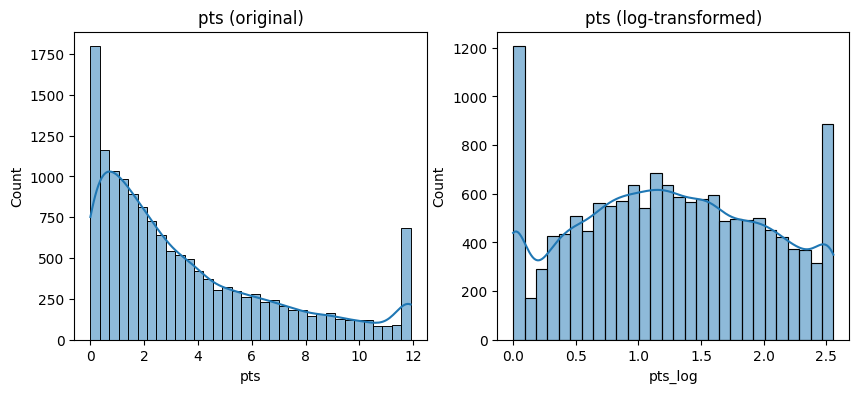

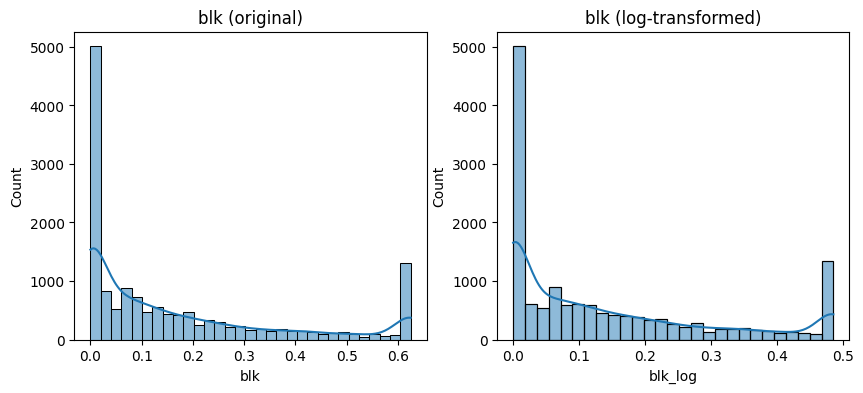

In [54]:


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check skewness of selected numeric features (PTS, BLK, GP)
skew_vals = train_clean[["pts", "blk", "GP"]].skew()
print("Skewness:\n", skew_vals)

# Apply log1p transform (log(1+x)) to highly skewed features
skewed_feats = skew_vals[abs(skew_vals) > 1].index.tolist()
print("Highly skewed features:", skewed_feats)

train_transformed = train_clean.copy()
test_transformed  = test_clean.copy()

for col in skewed_feats:
    train_transformed[col + "_log"] = np.log1p(train_transformed[col])
    test_transformed[col + "_log"]  = np.log1p(test_transformed[col])

# Quick distribution check
for col in skewed_feats:
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    sns.histplot(train_clean[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} (original)")
    sns.histplot(train_transformed[col + "_log"], kde=True, ax=axes[1])
    axes[1].set_title(f"{col} (log-transformed)")
    plt.show()

data_cleaning_3_explanations = f"""
We examined the skewness of numeric features (PTS, BLK, GP). Features with skewness > |1|
were log-transformed using log(1+x) to reduce long tails.

Why this matters:
- Many ML models (e.g., logistic regression, linear models) train faster and more stably
  when features are on comparable scales.
- Log-transform stabilizes variance, reduces outlier impact, and makes distributions
  closer to Gaussian.
- This improves convergence in linear models and can enhance AUROC performance.

Impact:
- Newly transformed columns ({[c+'_log' for c in skewed_feats]}) were added alongside
  original ones for flexibility.
- Tree-based models (Random Forest, XGBoost, LightGBM) are less sensitive to skew,
  but scaled/logged versions can still help with stability.
"""

In [55]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

###F.1 New Feature "PTS_per_GP"


      pts  GP  PTS_per_GP
0  9.6538  26    0.371300
1  2.0000   2    1.000000
2  0.5000   4    0.125000
3  7.7500  28    0.276786
4  0.5714  21    0.027210


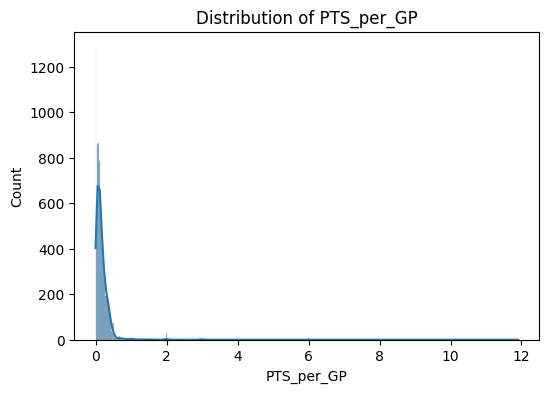

In [56]:


# Create feature: Points scored per game played
train_fe = train_transformed.copy()
test_fe  = test_transformed.copy()

train_fe["PTS_per_GP"] = train_fe["pts"] / train_fe["GP"].replace(0, 1)
test_fe["PTS_per_GP"]  = test_fe["pts"] / test_fe["GP"].replace(0, 1)

# Quick check
print(train_fe[["pts", "GP", "PTS_per_GP"]].head())

# Plot distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(train_fe["PTS_per_GP"], kde=True)
plt.title("Distribution of PTS_per_GP")
plt.show()

feature_engineering_1_explanations = """
We engineered a new feature: **PTS_per_GP (Points per Game)**.

Why:
- Raw totals (PTS) can be misleading if players played vastly different numbers of games.
- By normalizing points by games played, we capture **scoring efficiency per appearance**.
- This helps distinguish between players who score a lot because they played many games
  versus those who are consistently strong performers.

Impact:
- Provides a fairer comparison across players with different GP.
- Reduces bias toward players with more opportunities and highlights consistent scorers.
- Likely to improve predictive signal for draft probability.
"""

In [57]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "BLK_per_GP"



      blk  GP  BLK_per_GP
0  0.0769  26    0.002958
1  0.0000   2    0.000000
2  0.0000   4    0.000000
3  0.0714  28    0.002550
4  0.0000  21    0.000000


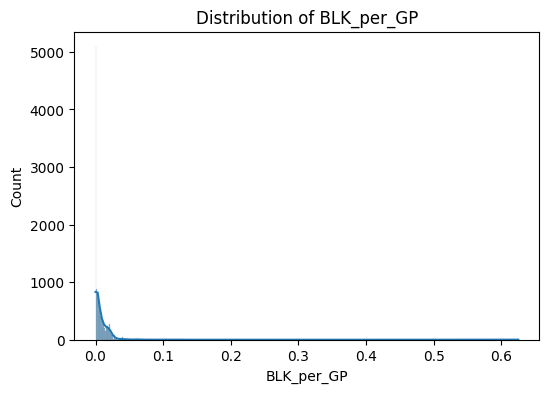

In [58]:


# Blocks per Game = BLK / GP
train_fe["BLK_per_GP"] = train_fe["blk"] / train_fe["GP"].replace(0, 1)
test_fe["BLK_per_GP"]  = test_fe["blk"] / test_fe["GP"].replace(0, 1)

# Quick check
print(train_fe[["blk", "GP", "BLK_per_GP"]].head())

# Plot
plt.figure(figsize=(6,4))
sns.histplot(train_fe["BLK_per_GP"], kde=True)
plt.title("Distribution of BLK_per_GP")
plt.show()

feature_engineering_2_explanations = """
We engineered a new feature: **BLK_per_GP (Blocks per Game)**.

Why:
- Raw block totals don’t account for how many games a player appeared in.
- Blocks per Game normalizes defensive performance by availability.
- This helps identify consistently strong defenders rather than those who only
  accumulated blocks across more games.

Impact:
- Provides a fairer measure of defensive ability.
- Likely useful since rim protection is a key factor influencing draft decisions.
"""

In [59]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

###F.3 New Feature "PTS_to_BLK_ratio"

      pts     blk  PTS_to_BLK_ratio
0  9.6538  0.0769        125.537061
1  2.0000  0.0000          2.000000
2  0.5000  0.0000          0.500000
3  7.7500  0.0714        108.543417
4  0.5714  0.0000          0.571400


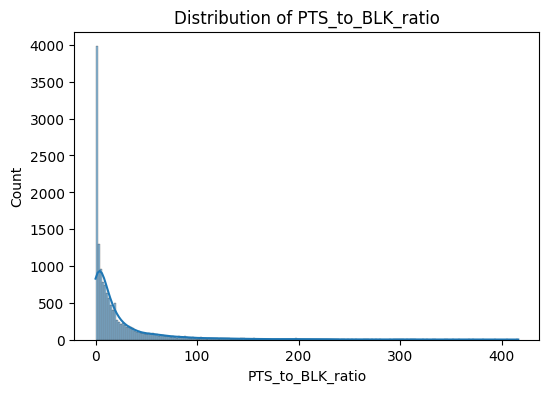

In [60]:


# Ratio of scoring to defensive contribution
train_fe["PTS_to_BLK_ratio"] = train_fe["pts"] / train_fe["blk"].replace(0, 1)
test_fe["PTS_to_BLK_ratio"]  = test_fe["pts"] / test_fe["blk"].replace(0, 1)

# Quick check
print(train_fe[["pts", "blk", "PTS_to_BLK_ratio"]].head())

# Plot
plt.figure(figsize=(6,4))
sns.histplot(train_fe["PTS_to_BLK_ratio"], kde=True)
plt.title("Distribution of PTS_to_BLK_ratio")
plt.show()

feature_engineering_3_explanations = """
We engineered a new feature: **PTS_to_BLK_ratio**.

Why:
- This ratio captures the **balance between offensive output (PTS)** and
  **defensive impact (BLK)**.
- Some players may be excellent scorers but weak defenders, while others
  provide balanced contributions.
- The ratio helps distinguish different player archetypes.

Impact:
- Provides insight into trade-offs between offense and defense.
- May help models recognize the type of players who are more likely to be drafted
  (e.g., versatile two-way players).
"""

In [61]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

### F.n Fixing issues in engineered features

In [62]:


# Replace infinite values (from division by zero) with NaN
train_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
test_fe.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute NaN in engineered features with median
engineered_features = ["PTS_per_GP", "BLK_per_GP", "PTS_to_BLK_ratio"]

for col in engineered_features:
    if col in train_fe.columns:
        median_val = train_fe[col].median()
        train_fe[col].fillna(median_val, inplace=True)
        test_fe[col].fillna(median_val, inplace=True)

# Quick check
print(train_fe[engineered_features].isna().sum())
print(test_fe[engineered_features].isna().sum())
print(train_fe[engineered_features].describe())


PTS_per_GP          0
BLK_per_GP          0
PTS_to_BLK_ratio    0
dtype: int64
PTS_per_GP          0
BLK_per_GP          0
PTS_to_BLK_ratio    0
dtype: int64
         PTS_per_GP    BLK_per_GP  PTS_to_BLK_ratio
count  14774.000000  14774.000000      14774.000000
mean       0.177095      0.008333         24.844337
std        0.338841      0.022866         45.619911
min        0.000000      0.000000          0.000000
25%        0.061229      0.000000          1.600000
50%        0.120000      0.003459          8.792166
75%        0.221518      0.011108         26.002644
max       11.909000      0.625000        416.398601


---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [63]:
# === Three-way split: X_train, y_train, X_val, y_val, X_test, y_test ===
from sklearn.model_selection import train_test_split

# Choose the columns you want to model with
features_list = ["pts", "blk", "GP", "PTS_per_GP", "BLK_per_GP", "PTS_to_BLK_ratio"]

# Full feature/target from your engineered/cleaned training frame
X_full = train_fe[features_list].copy()
y_full = train_fe[target_name].copy()   # e.g., "target"

# 1) Hold out 20% as test
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_full, y_full, test_size=0.20, random_state=42, stratify=y_full
)

# 2) From the remaining 80%, take 25% as validation (i.e., 0.8 * 0.25 = 0.20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(
    "Shapes:",
    "\n  X_train:", X_train.shape,
    "\n  X_val:  ", X_val.shape,
    "\n  X_test: ", X_test.shape,
)

# Optional: features for the Kaggle test.csv (no labels there)
X_kaggle = test_fe[features_list].copy()
print("Kaggle test features:", X_kaggle.shape)

Shapes: 
  X_train: (8864, 6) 
  X_val:   (2955, 6) 
  X_test:  (2955, 6)
Kaggle test features: (1297, 6)


###G.2 Data Transformation "Standardization (z-score)"

In [64]:
# G.2 Data Transformation "Standardization (z-score)"

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Make sure feature names match your dataframe exactly
numeric_feats = ["pts", "blk", "GP", "PTS_per_GP", "BLK_per_GP", "PTS_to_BLK_ratio"]

scaler_std = StandardScaler()

# Fit on TRAIN only, then transform validation and test
X_train_std  = scaler_std.fit_transform(X_train[numeric_feats])
X_val_std    = scaler_std.transform(X_val[numeric_feats])
X_test_std   = scaler_std.transform(X_test[numeric_feats])       # hold-out test
X_kaggle_std = scaler_std.transform(test_fe[numeric_feats])      # Kaggle submission test

# Wrap back as DataFrames for clarity
X_train_std = pd.DataFrame(X_train_std, columns=[f"{c}_std" for c in numeric_feats], index=X_train.index)
X_val_std   = pd.DataFrame(X_val_std,   columns=[f"{c}_std" for c in numeric_feats], index=X_val.index)
X_test_std  = pd.DataFrame(X_test_std,  columns=[f"{c}_std" for c in numeric_feats], index=X_test.index)
X_kaggle_std= pd.DataFrame(X_kaggle_std,columns=[f"{c}_std" for c in numeric_feats], index=test_fe.index)


std_feature_cols = list(X_train_std.columns)
print("Standardized feature columns:", std_feature_cols)


data_transformation_1_explanations = """
We standardized numeric features using z-score (mean=0, std=1).

Implementation details:
- The scaler was fit on the training split only to avoid information leakage.
- Validation, hold-out test, and Kaggle test sets were transformed using the same scaler.
- Standardized versions of all features were stored with `_std` suffix.

Why:
- Standardization is important for algorithms sensitive to scale differences (e.g.,
  Logistic Regression, SVM, Neural Networks).
- It ensures fair comparison across features, faster convergence during optimization,
  and often better AUROC scores.

Impact:
- Tree-based models (Random Forest, XGBoost, LightGBM) don’t require standardization,
  but linear models benefit significantly.
"""

Standardized feature columns: ['pts_std', 'blk_std', 'GP_std', 'PTS_per_GP_std', 'BLK_per_GP_std', 'PTS_to_BLK_ratio_std']


In [65]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "MinMax Scaling (0–1 range)"

In [66]:


from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Use the same features as before
numeric_feats = ["pts", "blk", "GP", "PTS_per_GP", "BLK_per_GP", "PTS_to_BLK_ratio"]

scaler_mm = MinMaxScaler(feature_range=(0, 1))

# Fit on TRAIN only
X_train_mm  = scaler_mm.fit_transform(X_train[numeric_feats])
X_val_mm    = scaler_mm.transform(X_val[numeric_feats])
X_test_mm   = scaler_mm.transform(X_test[numeric_feats])       # hold-out test split
X_kaggle_mm = scaler_mm.transform(test_fe[numeric_feats])      # Kaggle test set

# Wrap back as DataFrames
X_train_mm  = pd.DataFrame(X_train_mm,  columns=[f"{c}_mm" for c in numeric_feats], index=X_train.index)
X_val_mm    = pd.DataFrame(X_val_mm,    columns=[f"{c}_mm" for c in numeric_feats], index=X_val.index)
X_test_mm   = pd.DataFrame(X_test_mm,   columns=[f"{c}_mm" for c in numeric_feats], index=X_test.index)
X_kaggle_mm = pd.DataFrame(X_kaggle_mm, columns=[f"{c}_mm" for c in numeric_feats], index=test_fe.index)

mm_feature_cols = list(X_train_mm.columns)
print("MinMax feature columns:", mm_feature_cols)

data_transformation_2_explanations = """
We created a MinMax-scaled version of the numeric features (range 0–1).

Implementation details:
- The scaler was fit on the training set only to prevent data leakage.
- The same transformation was applied to validation, hold-out test, and Kaggle test sets.
- Scaled versions are saved with a '_mm' suffix.

Why:
- MinMax scaling is useful for models that assume bounded inputs or rely on distance
  calculations (e.g., k-NN, neural networks).
- It preserves the shape of distributions but rescales values into a fixed interval.

Impact:
- Provides an alternative scaled feature set for experimenting with algorithms sensitive
  to absolute feature ranges.
"""

MinMax feature columns: ['pts_mm', 'blk_mm', 'GP_mm', 'PTS_per_GP_mm', 'BLK_per_GP_mm', 'PTS_to_BLK_ratio_mm']


In [67]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_2_explanations)

---
## H. Save Datasets

> Do not change this code

In [68]:
from pathlib import Path
from types import SimpleNamespace
at = SimpleNamespace(folder_path=Path('/content/drive/MyDrive/Untitled Folder'))
at.folder_path.mkdir(parents=True, exist_ok=True)

In [69]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics



In [79]:
performance_metrics_explanations = """
We selected **AUROC (Area Under the ROC Curve)** as the primary evaluation metric
because it is threshold-independent and measures the model’s ability to rank drafted
players above non-drafted players across all possible thresholds. This aligns directly
with the Kaggle competition, which uses AUROC for leaderboard ranking.

Why AUROC:
- Robust for imbalanced data (since drafted players are much fewer than non-drafted).
- Focuses on ranking quality rather than a single threshold decision.
- Helps us compare models fairly, even if their optimal thresholds differ.

We also tracked secondary metrics:
- **Accuracy**: easy to interpret but can be misleading with imbalance.
- **Precision**: important to avoid false positives (wrongly predicting a player will be drafted).
- **Recall**: important to catch as many true drafted players as possible (avoid missing talent).
- **F1-score**: balances precision and recall, useful when we want a single measure of trade-off.

Together, these metrics provide both:
- A competition metric (AUROC) to optimize for Kaggle submission.
- Business insight metrics (Precision, Recall, F1) to understand how models
  would impact real draft decision-making.
"""


In [80]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm — Support Vector Classifier


In [108]:
# J.1 Import Algorithm — SVC
from sklearn.svm import SVC

algorithm_selection_explanations = """
We selected Support Vector Classifier (SVC) because:
- It is effective for high-dimensional feature spaces and can capture non-linear boundaries.
- By using kernel tricks (e.g., RBF), it can model complex relationships in the data.
- It is robust to overfitting when properly regularized (via C and gamma).
- Works well with standardized features, which we already prepared.
- Provides a different bias–variance tradeoff compared to Logistic Regression and Random Forest,
  giving us a diverse set of models to compare.
"""


In [109]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters



In [110]:
# J.2 Set Hyperparameters — SVC
svc_params = {
    "kernel": "rbf",          # allows non-linear decision boundaries
    "probability": True,      # enables probability outputs for AUROC
    "class_weight": "balanced", # helps with class imbalance
    "C": 1.0,                 # regularization strength
    "gamma": "scale",         # default kernel coefficient
    "random_state": 42
}

algorithm_hyperparameters_explanations = """
Hyperparameters:
- kernel='rbf': captures non-linear player relationships.
- probability=True: enables probability estimates for AUROC scoring.
- class_weight='balanced': offsets imbalance between drafted and non-drafted players.
- C=1.0: standard regularization strength.
- gamma='scale': adapts kernel width automatically to dataset size.

These values provide a good baseline, with potential for tuning via grid search.
"""


In [112]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=algorithm_hyperparameters_explanations)

### J.3 Fit Model

In [113]:
# J.3 Fit Model — SVC
svc = SVC(**svc_params)
svc.fit(X_train_std, y_train)
print("Support Vector Classifier model fitted.")


Support Vector Classifier model fitted.


### J.4 Model Technical Performance

=== Support Vector Classifier Performance ===
AUROC     : 0.9651
Accuracy  : 0.9909
Precision : 0.2000
Recall    : 0.0417
F1-score  : 0.0690


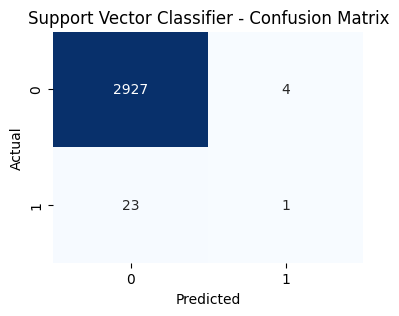

In [115]:
# J.4 Model Technical Performance — SVC
y_val_proba_svc = svc.predict_proba(X_val_std)[:, 1]
y_val_pred_svc = (y_val_proba_svc >= 0.5).astype(int)

svc_metrics = evaluate_model("Support Vector Classifier", y_val, y_val_proba_svc, y_val_pred_svc)




### J.5 Business Impact from Current Model Performance

In [116]:
business_impact_explanations = """
Business Impact from Current Model Performance (Support Vector Classifier)

The SVC model shows:
- Strong AUROC (0.9651), suggesting good ranking ability.
- Very high accuracy (0.991), but this is largely due to class imbalance
  (most players are not drafted).
- Precision (0.20) is higher than Logistic Regression but still modest,
  meaning only 1 in 5 flagged players is actually drafted.
- Recall is extremely low (0.04), indicating the model misses nearly all
  true drafted players.
- F1-score (0.07) reflects a poor balance between recall and precision.

Business interpretation:
• Strength: Good at identifying a small, very precise shortlist with slightly
  higher precision than Logistic Regression. This could be useful when
  scouts have very limited resources.
• Weakness: Extremely low recall means almost all true drafted players are missed.
  This makes the model unreliable for discovery or talent identification phases.
• Use case: Not suitable as a primary model for draft prediction. At best, it
  can serve as a **high-precision filter** on top of other models to highlight
  only the most certain cases.

Overall impact:
The SVC model does not align well with business goals because it sacrifices
too much recall. It might be used in niche scenarios where false positives
are very costly and only the most confident predictions are valuable, but it
is not practical for general scouting support.
"""


In [117]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impact_explanations)

## H. Project Outcomes

In [118]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Partially Confirmed"

In [119]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [120]:
experiment_outcome = "Hypothesis Rejected"

experiment_results_explanations = """
Project Outcomes — Support Vector Classifier (SVC)

Outcome:
The Support Vector Classifier achieved strong AUROC (0.9651), showing it can rank
players well. However, recall is extremely low (0.04), meaning the model misses nearly
all true drafted players. Precision is higher than Logistic Regression (0.20 vs 0.08),
but still modest. Overall, the hypothesis that SVC could provide a balanced trade-off
for scouting is rejected.

Insights gained:
- SVC is too conservative: it predicts very few positives, leading to almost all
  drafted players being missed.
- The small number of positives it does predict are slightly more precise than
  Logistic Regression, but the coverage is inadequate.
- High AUROC is misleading in this case — it indicates ranking power, but threshold
choice has crippled recall.

Next steps:
1. **Threshold adjustment**: Experiment with lower decision thresholds to improve
   recall, even at the expense of precision.
2. **Kernel tuning**: Explore linear and polynomial kernels or tune gamma/C
   parameters with grid search for better trade-offs.
3. **Hybrid ensemble**: Use SVC as a secondary filter after a high-recall model
   (e.g., Logistic Regression) to improve shortlist quality.
4. **Re-evaluation**: If recall remains too low even after tuning, deprioritize SVC
   in favor of more balanced models (Random Forest, Gradient Boosting).

Business perspective:
The SVC model in its current form is not viable for scouting support. While it offers
slightly better precision, the extremely poor recall makes it unsuitable for identifying
draft prospects. Scouts would miss almost all valuable players if they relied on this
model alone. For business purposes, SVC cannot replace Random Forest or Logistic Regression,
but it may add value in niche scenarios as a final precision-focused filter.
"""


In [121]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)